# Korrelation zwischen Alphabetisierungsrate und BIP pro Kopf

## Gruppe: 
Lia Bütikofer (buetilia@students.zhaw.ch), Vanessa Cakoncev (cakonvan@students.zhaw.ch), Lilia Totila (totillil@students.zhaw.ch)


## Fragestellung
Besteht ein Zusammenhang zwischen dem Bruttoinlandsprodukt (BIP) pro Kopf und der Analphabetisierungsrate, und wie zeigt sich dieser Zusammenhang weltweit, sowie in ausgewählten Ländern?

## Quellen
Für die Analyse wurden folgende Quelle gebraucht:
https://ourworldindata.org/grapher/literacy-rate-vs-gdp-per-capita

Für die Auswertungen wurden folgende Quellen genommen:
- UNICEF. (2023, October 9). 19 million children in Sudan out of school as conflict rages on. UNICEF. https://www.unicef.org/sudan/press-releases/19-million-children-sudan-out-school-conflict-rages-unicef-save-children 
- APA-Quelle:
Wikipedia. (2025). Irak [Eintrag zur Alphabetisierung und Bildung]. In Wikipedia. https://de.wikipedia.org/wiki/Irak 
- AP News. (2025, October 31). Syrian students return to schools stripped bare by conflict. https://apnews.com/article/8976fac6649c000a2c9a4876e734a82f 


## 1. Daten beschaffen und laden

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Konifugarion
file_path = "literacy-rate-vs-gdp-per-capita.csv"
start_year = 1990
end_year = 2023
target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 
pd.set_option('display.max_rows', 10) # Setzt die maximale Zeilenanzahl für eine übersichtlichere Ausgabe

# Daten laden & globale Filterung

try:
    df_rohdaten = pd.read_csv(file_path)
except FileNotFoundError:
    print("FATALER FEHLER: Die Datei 'literacy-rate-vs-gdp-per-capita.csv' wurde nicht gefunden.")
    print("Bitte stellen Sie sicher, dass die Datei im selben Verzeichnis wie das Notebook liegt.")
    exit()

# Sicherstellen, dass die Spalte 'Year' numerisch ist
df_rohdaten['Year'] = pd.to_numeric(df_rohdaten['Year'], errors='coerce')

# Global gefilterter DataFrame (Weltweit, 1990-2023)
df_global_filtered = df_rohdaten[
    (df_rohdaten['Year'] >= start_year) & 
    (df_rohdaten['Year'] <= end_year)
].copy()

# Spalten umbenennen

df_global_filtered.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    'Literacy rate among adults': 'Alphabetisierungsrate',
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)

# Spezifischer DataFrame für 4 Zielländer
df_zielgruppe = df_global_filtered[df_global_filtered['Land'].isin(target_countries)].copy()
df_zielgruppe['Analphabetisierungsrate (%)'] = 100 - df_zielgruppe['Alphabetisierungsrate']


print("--- BASIS-DATENFRAMES ERSTELLT ---")
print("Für globale Analysen: df_global_filtered")
print("Für Länderspezifische Analysen: df_zielgruppe")

--- BASIS-DATENFRAMES ERSTELLT ---
Für globale Analysen: df_global_filtered
Für Länderspezifische Analysen: df_zielgruppe


In [3]:
df = pd.read_csv("literacy-rate-adults.csv")
df_gdp = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")
df.head()

,Entity,Code,Year,"Literacy rate, adult total (% of people ages 15 and above)"
0,Afghanistan,AFG,1979,18.00000
1,Afghanistan,AFG,2011,31.00000
2,Afghanistan,AFG,2015,33.75384
3,Afghanistan,AFG,2021,37.00000
4,Albania,ALB,2001,99.00000


# 2 Analyse der Daten

## 2.1 Analyse der Länder


In [4]:
import pandas as pd

# Laden der Haupt-Quelldatei
df_rohdaten = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

# Korrekte Zählung: 'Entity' ist der Name der Länder-Spalte in der Rohdatei.
anzahl_laender = df_rohdaten["Entity"].nunique()

# Ausgabe der Zählung
print("Anzahl verschiedener Länder:", anzahl_laender)

Anzahl verschiedener Länder: 310


In [5]:
df["Entity"].value_counts().head(10)
# Ausgabe der Datenpunkte pro Land bzw. Region

Entity
Latin America and Caribbean (WB)                            50
Middle East, North Africa, Afghanistan and Pakistan (WB)    50
Lower-middle-income countries                               49
South Asia (WB)                                             49
East Asia and Pacific (WB)                                  48
World                                                       48
Upper-middle-income countries                               48
Sub-Saharan Africa (WB)                                     39
Low-income countries                                        36
Europe and Central Asia (WB)                                30
Name: count, dtype: int64

In [6]:
df.dtypes
# Ausgabe der "Datentypen" in der Liste

Entity                                                         object
Code                                                           object
Year                                                            int64
Literacy rate, adult total (% of people ages 15 and above)    float64
dtype: object

## 2.2 Analyse der Jahre

In [7]:
print(df.columns)
# Anzeige der Spalten in der Liste


Index(['Entity', 'Code', 'Year',
       'Literacy rate, adult total (% of people ages 15 and above)'],
      dtype='object')


In [8]:
df_clean = df[df["Year"] >= 1985]
# Festsetzen des Anfangsjahres, bzw. Zeitraum festsetzten, wo wir unsere Analyse durchführen


In [9]:
print("\n--- Zeitspanne des bereinigten Datensatzes ---")
print(f"Erstes Jahr: {df_clean['Year'].min()}")
print(f"Letztes Jahr: {df_clean['Year'].max()}")



--- Zeitspanne des bereinigten Datensatzes ---
Erstes Jahr: 1985
Letztes Jahr: 2023


Im Datensatz waren ungültige Jahreswerte (−10000) enthalten, die als Platzhalter für fehlende Zeitangaben dienen. Diese Werte wurden vor der Analyse entfernt und ersetzt, um eine realistische zeitliche Auswertung zu gewährleisten.

## 2.3 Analyse mit Fokus auf vier Länder
Für eine vertiefte Analyse wurden vier Länder ausgewählt: Afghanistan, Irak, Sudan und Syrien. Diese Länder unterscheiden sich in ihren wirtschaftlichen Wohlstand als auch in ihrer politischen Stabilität und eignen sich dahers besonders für einen Vergleich.

In [10]:
print("### Überprüfung des gefilterten DataFrames (df_zielgruppe) ###")
print(f"Der gefilterte DataFrame enthält {len(df_zielgruppe)} Zeilen.")
print("\nErste 5 Zeilen zur Kontrolle:")

print(df_zielgruppe.head().to_markdown())


### Überprüfung des gefilterten DataFrames (df_zielgruppe) ###
Der gefilterte DataFrame enthält 136 Zeilen.

Erste 5 Zeilen zur Kontrolle:
|    | Land        | Code   |   Jahr |   Alphabetisierungsrate |   BIP pro Kopf |   Population (historical) |   World regions according to OWID |   Analphabetisierungsrate (%) |
|---:|:------------|:-------|-------:|------------------------:|---------------:|--------------------------:|----------------------------------:|------------------------------:|
|  1 | Afghanistan | AFG    |   2011 |                 31      |        2757.05 |               2.93477e+07 |                               nan |                       69      |
|  2 | Afghanistan | AFG    |   2015 |                 33.7538 |        2967.69 |               3.38318e+07 |                               nan |                       66.2462 |
|  3 | Afghanistan | AFG    |   2021 |                 37      |        2144.17 |               4.00004e+07 |                               nan |    

In [11]:
import pandas as pd

countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 

df = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

# Filterung: Länder und Zeitrahmen 1990-2023
df_laender = df[
    df['Entity'].isin(countries) & 
    (df['Year'] >= 1990) & 
    (df['Year'] <= 2023)
].copy()

# Umbenennung
df_laender.rename(columns={'Entity': 'Land', 'Year': 'Jahr'}, inplace=True)

print(
    df_laender
    .groupby("Land")["Jahr"]
    .count()
    .sort_index()
    .to_frame("Anzahl Datenpunkte")
    .to_markdown()
)

| Land        |   Anzahl Datenpunkte |
|:------------|---------------------:|
| Afghanistan |                   34 |
| Iraq        |                   34 |
| Sudan       |                   34 |
| Syria       |                   34 |


In [12]:
df_laender.groupby("Land")["Jahr"].agg(["min", "max"])

,min,max
Land,,
Afghanistan,1990,2023
Iraq,1990,2023
Sudan,1990,2023
Syria,1990,2023


In [13]:
df_zielgruppe["Analphabetisierungsrate (%)"].describe()
# schriftlicher Boxplot, der 4 Länder

count    13.000000
mean     32.557397
std      21.748104
min       6.000000
25%      17.000000
50%      23.000000
75%      46.000000
max      69.000000
Name: Analphabetisierungsrate (%), dtype: float64

In [14]:
meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"]


In [15]:
df.columns
# Spalten der Liste der 4 Länder

Index(['Entity', 'Code', 'Year', 'Literacy rate among adults',
       'GDP per capita, PPP (constant 2021 international $)',
       'Population (historical)', 'World regions according to OWID'],
      dtype='object')

In [16]:
meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"]

df_zeit = df[(df["Year"] >= 1985) & (df["Year"] <= 2023)]

print("\n--- Zeitliche Abdeckung der ausgewählten Länder ---")

for land in meine_laender:
    land_df = df_zeit[df_zeit["Entity"] == land]

    if land_df.empty:
        print(f"{land}: keine Daten vorhanden")
    else:
        print(
            f"{land}: {land_df['Year'].min()} – {land_df['Year'].max()} "
            f"({land_df.shape[0]} Datenpunkte)"
        )
# Die zeitliche Abdeckung der Länder, mit der Anzahl Datenpunkte pro Land (4 Länder)


--- Zeitliche Abdeckung der ausgewählten Länder ---
Afghanistan: 1985 – 2023 (39 Datenpunkte)
Iraq: 1985 – 2023 (39 Datenpunkte)
Sudan: 1985 – 2023 (39 Datenpunkte)
Syria: 1985 – 2023 (39 Datenpunkte)


Die Jahre vor 1985 wurden aus der Analyse ausgeschlossen, da sie entweder unvollständig, historisch nicht vergleichbar oder als Platzhalterwerte im Datensatz enthalten waren.
Die Analyse konzentriert sich daher auf den Zeitraum 1985–2023, für den konsistente und vergleichbare Daten vorliegen.
Die zeitliche Abdeckung der Daten variiert je nach Land. Für Sudan liegen Daten von 1985 bis 2023 vor, während für Syrien aufgrund politischer Instabilität nur bis 2018 konsistente Werte verfügbar sind. Afghanistan und Irak weisen ebenfalls Lücken auf, insbesondere in Phasen bewaffneter Konflikte.
Diese Unterschiede müssen bei der Interpretation der Ergebnisse berücksichtigt werden.

## 2.4 Weltweite Analphabetisierung und BIP

In [17]:
import pandas as pd
import numpy as np



file_path = "literacy-rate-vs-gdp-per-capita.csv"
target_countries = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 
start_year = 1990
end_year = 2023


try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"FEHLER: Die Datei '{file_path}' konnte nicht gefunden werden. Bitte Pfad prüfen.")
    exit()

# Filterung und Umbenennung auf die Zielgruppe (df_zielgruppe), um die Berechnung auf sauberen Daten durchzuführen
df.rename(columns={'Entity': 'Land', 'Year': 'Jahr'}, inplace=True)
df_zielgruppe = df[
    df['Land'].isin(target_countries) &
    (df['Jahr'] >= start_year) &
    (df['Jahr'] <= end_year)
].copy()




# Originale Spalte: "Literacy rate among adults"
original_col = "Literacy rate among adults"

# Neue Spalte: "Analphabetisierungsrate (%)" (wie in den finalen Codes verwendet)
new_col = "Analphabetisierungsrate (%)"

if original_col in df_zielgruppe.columns:
    # Berechnung: 100 - Alphabetisierungsrate
    df_zielgruppe[new_col] = 100 - df_zielgruppe[original_col]
    
    print(f"### Berechnung der '{new_col}' abgeschlossen. ###")
    print("\nErste 5 Zeilen zur Überprüfung der neuen Spalte:")
    
    
    print(df_zielgruppe[['Land', 'Jahr', original_col, new_col]].head().to_markdown(index=False))

else:
    print(f"FEHLER: Die Spalte '{original_col}' wurde nicht im DataFrame gefunden.")


### Berechnung der 'Analphabetisierungsrate (%)' abgeschlossen. ###

Erste 5 Zeilen zur Überprüfung der neuen Spalte:
| Land        |   Jahr |   Literacy rate among adults |   Analphabetisierungsrate (%) |
|:------------|-------:|-----------------------------:|------------------------------:|
| Afghanistan |   2011 |                      31      |                       69      |
| Afghanistan |   2015 |                      33.7538 |                       66.2462 |
| Afghanistan |   2021 |                      37      |                       63      |
| Afghanistan |   2000 |                     nan      |                      nan      |
| Afghanistan |   2001 |                     nan      |                      nan      |


In [18]:
import pandas as pd

# Daten vorbereiten
file_path = "literacy-rate-vs-gdp-per-capita.csv"
start_year = 1990
end_year = 2023

try:
    df_rohdaten = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"FEHLER: Die Datei '{file_path}' konnte nicht gefunden werden.")
    exit()

# Umbenennen und Filtern 
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    'Literacy rate among adults': 'Alphabetisierungsrate'
}, inplace=True)

df_global_filtered = df_rohdaten[
    (df_rohdaten['Jahr'] >= start_year) & 
    (df_rohdaten['Jahr'] <= end_year)
].copy()

# Berechnung der Analphabetisierungsrate (100 - Alphabetisierungsrate)
df_global_filtered['Analphabetisierungsrate (%)'] = 100 - df_global_filtered['Alphabetisierungsrate']




# Korrekter Spaltenname: 'Analphabetisierungsrate (%)'
welt = (
    df_global_filtered
    .groupby("Jahr")["Analphabetisierungsrate (%)"]
    .mean()
    .reset_index()
)

print("Weltweite durchschnittliche Analphabetisierungsrate pro Jahr (Top 5) ###")

print(welt.head().to_markdown(index=False))


Weltweite durchschnittliche Analphabetisierungsrate pro Jahr (Top 5) ###
|   Jahr |   Analphabetisierungsrate (%) |
|-------:|------------------------------:|
|   1990 |                       25.5416 |
|   1991 |                       29.6006 |
|   1992 |                       28.8241 |
|   1993 |                       33.29   |
|   1994 |                       32.4382 |


# 3.Visualisierung der Daten

## 3.1 Weltweite Analphabetisierungsrate

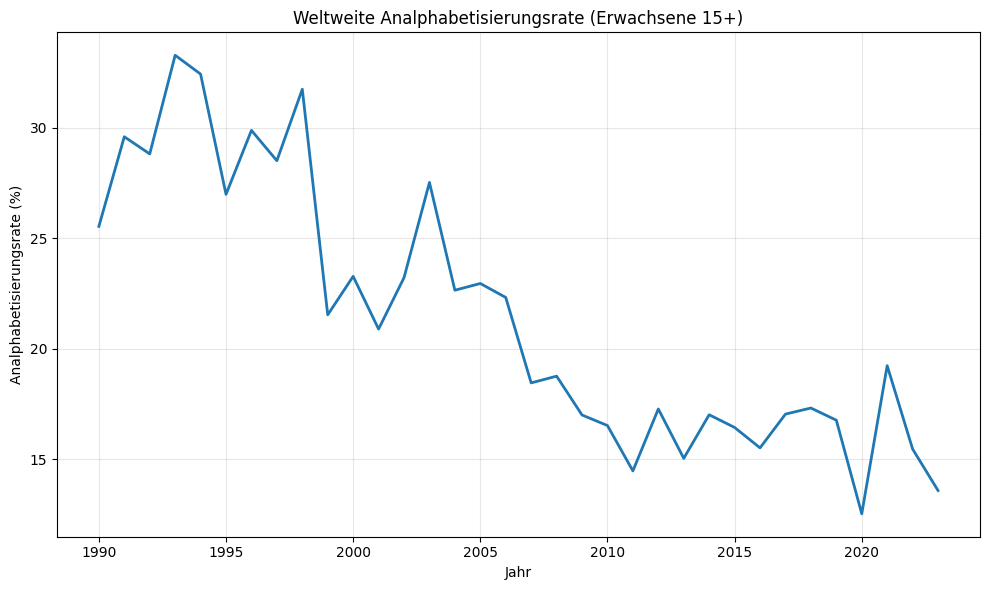

In [19]:
import pandas as pd
import matplotlib.pyplot as plt



df = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")
start_year = 1990
end_year = 2023

# Umbenennen und filtern (1985 - 2023)
df.rename(columns={'Year': 'Jahr', 'Literacy rate among adults': 'Alphabetisierungsrate'}, inplace=True)
df_global = df[(df['Jahr'] >= start_year) & (df['Jahr'] <= end_year)].copy()

# Berechnung der Analphabetisierungsrate
df_global['Analphabetisierungsrate (%)'] = 100 - df_global['Alphabetisierungsrate']

# Berechnung des weltweiten Durchschnitts pro Jahr
welt = df_global.groupby("Jahr")["Analphabetisierungsrate (%)"].mean().reset_index()



plt.figure(figsize=(10, 6))
plt.plot(
    welt["Jahr"],
    welt["Analphabetisierungsrate (%)"], 
    linewidth=2
)


plt.title("Weltweite Analphabetisierungsrate (Erwachsene 15+)")
plt.xlabel("Jahr")
plt.ylabel("Analphabetisierungsrate (%)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Die Grafik zeigt einen klaren langfristigen Abwärtstrend der weltweiten Analphabetisierungsrate. Während in früheren Jahren noch über 30 % der erwachsenen Weltbevölkerung nicht lesen und schreiben konnten, liegt der Wert in den jüngsten Jahren deutlich unter 15 %. Dies deutet auf einen globalen Fortschritt im Bildungsbereich hin.

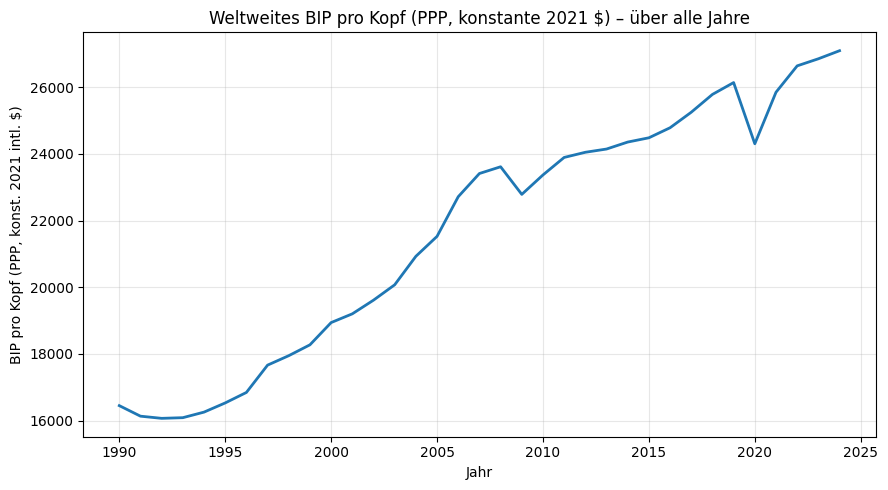

In [20]:

df_gdp = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

gdp_col = "GDP per capita, PPP (constant 2021 international $)"

# Weltweiter Jahresdurchschnitt 
world_gdp = (
    df_gdp.dropna(subset=[gdp_col])
    .groupby("Year")[gdp_col]
    .mean()
    .reset_index()
    .sort_values("Year")
)

# Code für Grafik
plt.figure(figsize=(9,5))
plt.plot(world_gdp["Year"], world_gdp[gdp_col], linewidth=2)
plt.title("Weltweites BIP pro Kopf (PPP, konstante 2021 $) – über alle Jahre")
plt.xlabel("Jahr")
plt.ylabel("BIP pro Kopf (PPP, konst. 2021 intl. $)")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Das weltweite BIP pro Kopf zeigt über den gesamten Beobachtungszeitraum einen deutlichen langfristigen Aufwärtstrend. Dies weist auf ein anhaltendes globales Wirtschaftswachstum und steigende durchschnittliche Lebensstandards hin.
Besonders starkes Wachstum ist ab den frühen 2000er-Jahren erkennbar, was unter anderem auf die zunehmende Globalisierung, den wirtschaftlichen Aufstieg von Schwellenländern sowie technologische Fortschritte zurückzuführen ist.

Der steigende Trend des weltweiten BIP pro Kopf steht in einem zeitlichen Zusammenhang mit dem gleichzeitigen Rückgang der globalen Analphabetisierungsrate. Dies unterstützt die Annahme, dass wirtschaftliches Wachstum den Ausbau von Bildungssystemen begünstigt, wenngleich kein direkter kausaler Zusammenhang nachgewiesen werden kann.

Die globale Entwicklung bildet jedoch nur einen groben Rahmen. Um die Ursachen niedriger Bildungsniveaus besser zu verstehen, werden im Folgenden Afghanistan, Irak, Sudan und Syrien detailliert betrachtet.

## 3.2 Vergleich der Analphabetisierungsrate der ausgewählten Länder (Afghanistan, Irak, Sudan, Syria)

In [21]:
import pandas as pd

file_path = "literacy-rate-vs-gdp-per-capita.csv"
countries = ["Afghanistan", "Iraq", "Sudan", "Syria"]
start_year = 1990
end_year = 2023

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print(f"FEHLER: Die Datei '{file_path}' konnte nicht gefunden werden.")
    exit()


df.rename(columns={'Entity': 'Land', 'Year': 'Jahr'}, inplace=True)



# Filterung auf unsere und Analysezeitraum (1985-2023)
df_laender = df[
    df["Land"].isin(countries) &
    (df["Jahr"] >= start_year) &
    (df["Jahr"] <= end_year)
].copy()

print("### Überblick über die gefilterten Daten der Zielländer (1990-2023) ###")
print(f"Es wurden {len(df_laender)} Zeilen gefunden.")

# Anzeige der ersten 5 Zeilen
print(df_laender.head().to_markdown(index=False))

### Überblick über die gefilterten Daten der Zielländer (1990-2023) ###
Es wurden 136 Zeilen gefunden.
| Land        | Code   |   Jahr |   Literacy rate among adults |   GDP per capita, PPP (constant 2021 international $) |   Population (historical) |   World regions according to OWID |
|:------------|:-------|-------:|-----------------------------:|------------------------------------------------------:|--------------------------:|----------------------------------:|
| Afghanistan | AFG    |   2011 |                      31      |                                               2757.05 |               2.93477e+07 |                               nan |
| Afghanistan | AFG    |   2015 |                      33.7538 |                                               2967.69 |               3.38318e+07 |                               nan |
| Afghanistan | AFG    |   2021 |                      37      |                                               2144.17 |               4.00004e+07 |         

In [22]:
import pandas as pd

FILE = "literacy-rate-vs-gdp-per-capita.csv"
COUNTRIES = ["Afghanistan", "Iraq", "Sudan", "Syria"]
START = 1990
END = 2023

try:
    df = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# Umbenennen + Berechnung Analphabetisierungsrate
df.rename(columns={
    'Entity': 'Land', 
    'Year': 'Jahr', 
    'Literacy rate among adults': 'Alphabetisierungsrate'
}, inplace=True)
df['Analphabetisierungsrate (%)'] = 100 - df['Alphabetisierungsrate']

df_filtered = df[
    df["Land"].isin(COUNTRIES) & 
    (df["Jahr"] >= START) & 
    (df["Jahr"] <= END)
].copy()

# Aktuellste Daten pro Land finden
aktuell = (
    df_filtered
    .sort_values("Jahr") 
    .groupby("Land", as_index=False)
    .tail(1)
    [["Land", "Jahr", "Analphabetisierungsrate (%)"]]
)

print("Aktuellste Analphabetisierungsrate pro Land")
print(aktuell.to_markdown(index=False))
print(" ")


Aktuellste Analphabetisierungsrate pro Land
| Land        |   Jahr |   Analphabetisierungsrate (%) |
|:------------|-------:|------------------------------:|
| Sudan       |   2023 |                           nan |
| Iraq        |   2023 |                           nan |
| Afghanistan |   2023 |                           nan |
| Syria       |   2023 |                           nan |
 


Für das Jahr 2023 liegen für die untersuchten Länder keine aktuellen Daten zur Analphabetisierungsrate vor.
Dies ist darauf zurückzuführen, dass Alphabetisierungsdaten nicht jährlich erhoben werden, sondern meist aus Volkszählungen oder groß angelegten Erhebungen stammen.
ür die Analyse wurde daher jeweils das zuletzt verfügbare Jahr pro Land verwendet.

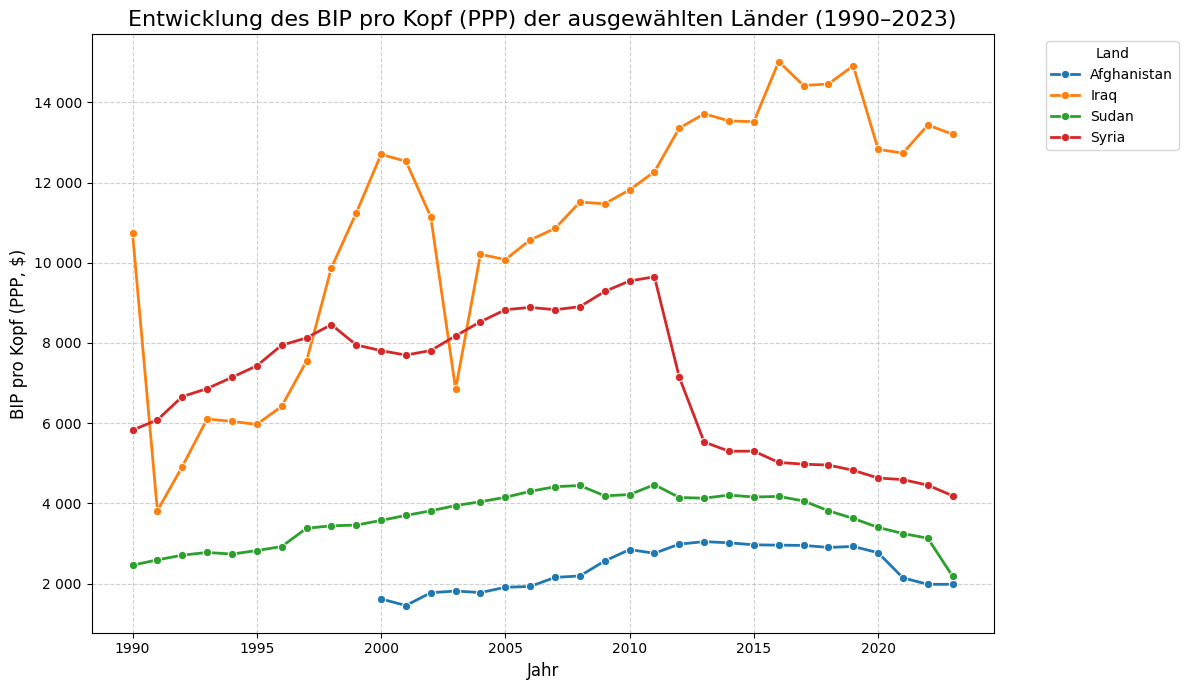

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter


FILE = "literacy-rate-vs-gdp-per-capita.csv"
COUNTRIES = ['Afghanistan', 'Sudan', 'Syria', 'Iraq'] 
START = 1990
END = 2023


try:
    df = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()


df.rename(columns={
    'Entity': 'Land', 
    'Year': 'Jahr', 
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)

df_filtered = df[
    df['Land'].isin(COUNTRIES) & 
    (df['Jahr'] >= START) & 
    (df['Jahr'] <= END)
].dropna(subset=['BIP pro Kopf']).copy() 



plt.figure(figsize=(12, 7))
sns.lineplot(
    data=df_filtered,
    x='Jahr',
    y='BIP pro Kopf',
    hue='Land', 
    marker='o',
    dashes=False,
    linewidth=2
)


# Formatierung der y-Achse mit Tausender-Trennzeichen
formatter = FuncFormatter(lambda x, pos: '{:,.0f}'.format(x).replace(',', ' '))
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Entwicklung des BIP pro Kopf (PPP) der ausgewählten Länder (1990–2023)', fontsize=16)
plt.xlabel('Jahr', fontsize=12)
plt.ylabel('BIP pro Kopf (PPP, $)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Land', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Der Vergleich der vier Länder zeigt, dass wirtschaftliche Entwicklung stark von politischer Stabilität abhängt. Während der Irak trotz Instabilität vergleichsweise hohe Einkommen erzielt, verdeutlichen Afghanistan, Sudan und Syrien, dass Konflikte und fragile staatliche Strukturen nachhaltiges Wachstum erheblich einschränken. Dabei hat jedes Land seinen eigenen Gründe für die Schwankungen in ihrem BIP:

Afghanistan
- langjähriger Krieg
- politische Instabilität

Irak
- 1990er Golfkrieg
- 2000er steigender BIP durch Öleinnahmen

Sudan
- politische Instabilität
Bürgerkriege
Wirtschaftliche Isolation

Syrien
- 2011 Start des Bürgerkrieges
- Zerstörung der sozialen und wirtschaftlichen Strukturen

In [24]:
df_gdp = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

df_gdp = df_gdp.rename(columns={
    "Entity": "Land",
    "Year": "Jahr",
    "GDP per capita, PPP (constant 2021 international $)": "BIP_pro_Kopf"
})

df_gdp.head()


,Land,Code,Jahr,Literacy rate among adults,BIP_pro_Kopf,Population (historical),World regions according to OWID
0,Afghanistan,AFG,1979,18.00000,NaN,13655575.0,NaN
1,Afghanistan,AFG,2011,31.00000,2757.0525,29347708.0,NaN
2,Afghanistan,AFG,2015,33.75384,2967.6921,33831767.0,NaN
3,Afghanistan,AFG,2021,37.00000,2144.1665,40000410.0,NaN
4,Afghanistan,AFG,2000,NaN,1617.8264,20130334.0,NaN


Hier haben wir erstmals einen direkten Vergleich zwischen dem BIP pro Kopf und der Analphabetisierung, aller Länder der Welt

In [25]:
import pandas as pd

df_gdp_laender = df.copy()

# Länder-Spalte
if "Entity" in df_gdp_laender.columns:
    df_gdp_laender = df_gdp_laender.rename(columns={"Entity": "Land"})

# Jahr-Spalte
year_col = "Year" if "Year" in df_gdp_laender.columns else "Jahr"

# GDP-Spalte finden
gdp_candidates = [
    "GDP per capita, PPP (constant 2021 international $)",
    "GDP per capita, PPP (constant 2021 intl. $)",
    "GDP per capita, PPP",
    "BIP pro Kopf",
    "BIP_pro_Kopf",
]
gdp_col_found = next((c for c in gdp_candidates if c in df_gdp_laender.columns), None)
if gdp_col_found is None:
    raise KeyError(f"Keine GDP-Spalte gefunden. Spalten sind: {df_gdp_laender.columns.tolist()}")

# Vereinheitlichen
df_gdp_laender = df_gdp_laender.rename(columns={
    year_col: "Year",
    gdp_col_found: "BIP_pro_Kopf"
})

# Aktuellster BIP-Wert pro Land
bip_aktuell = (
    df_gdp_laender
    .dropna(subset=["BIP_pro_Kopf"])
    .sort_values("Year")
    .groupby("Land", as_index=False)
    .tail(1)[["Land", "Year", "BIP_pro_Kopf"]]
)

bip_aktuell


,Land,Year,BIP_pro_Kopf
56463,United States Virgin Islands,2022,46479.3000
45624,San Marino,2022,70887.5700
51677,Syria,2023,4189.8374
40744,Palau,2023,15796.5350
54712,Tuvalu,2023,5812.3994
...,...,...,...
59485,Zimbabwe,2024,3450.1296
59222,Zambia,2024,3716.0374
12283,Croatia,2024,42631.3160
27618,Kuwait,2024,45426.9450


In [26]:
import pandas as pd


df_gdp_laender = df.copy()


df_gdp_laender = df_gdp_laender.rename(columns={"Entity": "Land", "Year": "Jahr"})


gdp_candidates = [
    "GDP per capita, PPP (constant 2021 international $)",
    "GDP per capita, PPP (constant 2021 intl. $)",
    "GDP per capita, PPP",
    "BIP pro Kopf",
    "BIP_pro_Kopf",
]

gdp_col_found = next((c for c in gdp_candidates if c in df_gdp_laender.columns), None)

if gdp_col_found is None:
    raise KeyError(f"Keine passende GDP-Spalte gefunden. Verfügbar sind: {df_gdp_laender.columns.tolist()}")


df_gdp_laender = df_gdp_laender.rename(columns={gdp_col_found: "BIP_pro_Kopf"})

# Aktuellster Wert pro Land
bip_aktuell = (
    df_gdp_laender
    .dropna(subset=["BIP_pro_Kopf"])
    .sort_values("Jahr")
    .groupby("Land", as_index=False)
    .tail(1)[["Land", "Jahr", "BIP_pro_Kopf"]]
)

bip_aktuell


,Land,Jahr,BIP_pro_Kopf
56463,United States Virgin Islands,2022,46479.3000
45624,San Marino,2022,70887.5700
51677,Syria,2023,4189.8374
40744,Palau,2023,15796.5350
54712,Tuvalu,2023,5812.3994
...,...,...,...
59485,Zimbabwe,2024,3450.1296
59222,Zambia,2024,3716.0374
12283,Croatia,2024,42631.3160
27618,Kuwait,2024,45426.9450


Hier sind die ausgewählten mit dem aktuellsten Stand ihres BIP's.

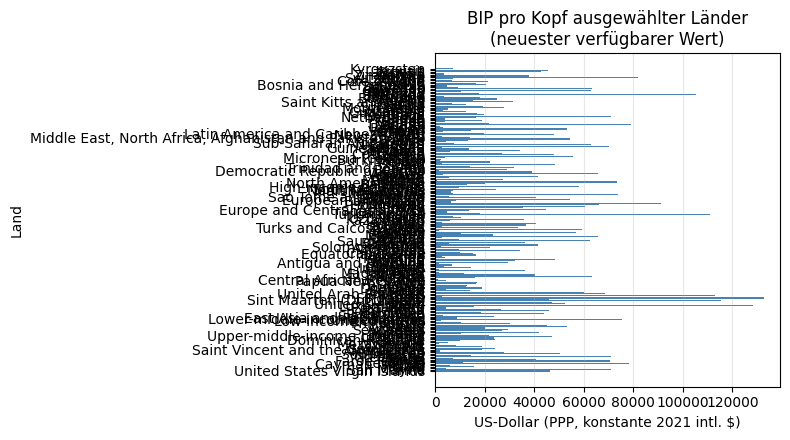

In [27]:
plt.figure(figsize=(8,4.5))

plt.barh(
    bip_aktuell["Land"],
    bip_aktuell["BIP_pro_Kopf"],
    color="steelblue"
)

plt.title("BIP pro Kopf ausgewählter Länder\n(neuester verfügbarer Wert)")
plt.xlabel("US-Dollar (PPP, konstante 2021 intl. $)")
plt.ylabel("Land")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


Der Vergleich des Bruttoinlandsprodukts pro Kopf zeigt deutliche wirtschaftliche Unterschiede zwischen den untersuchten Ländern.
Der Irak weist das höchste BIP pro Kopf auf, während Afghanistan und Sudan deutlich niedrigere Werte erreichen.
Diese Unterschiede liefern eine wichtige Grundlage für den Vergleich mit den Analphabetisierungsraten 


In [28]:
import pandas as pd


FILE = "literacy-rate-vs-gdp-per-capita.csv"
COUNTRIES = ["Afghanistan", "Iraq", "Sudan", "Syria"]
START = 1990
END = 2023

try:
    df = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# Umbenennen und Berechnen der Analphabetisierungsrate
df.rename(columns={
    'Entity': 'Land', 
    'Year': 'Jahr', 
    'Literacy rate among adults': 'Alphabetisierungsrate',
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)
df['Analphabetisierungsrate (%)'] = 100 - df['Alphabetisierungsrate']

df_filtered = df[
    df["Land"].isin(COUNTRIES) & 
    (df["Jahr"] >= START) & 
    (df["Jahr"] <= END)
].copy()

# Aktuellste Daten pro Land finden
aktuell_all = (
    df_filtered
    .sort_values("Jahr") 
    .groupby("Land", as_index=False)
    .tail(1)
)



# Analphabetisierung (ersetzt 'ana')
ana = aktuell_all[["Land", "Analphabetisierungsrate (%)"]]
 
# BIP (ersetzt 'bip') 
bip = aktuell_all[["Land", "BIP pro Kopf"]]
 
# Zusammenführen beider Daten
vergleich = ana.merge(bip, on="Land")

print("### Vergleich der aktuellsten Analphabetisierungsrate und des BIP pro Kopf pro Land ###")
print(vergleich.to_markdown(index=False))


### Vergleich der aktuellsten Analphabetisierungsrate und des BIP pro Kopf pro Land ###
| Land        |   Analphabetisierungsrate (%) |   BIP pro Kopf |
|:------------|------------------------------:|---------------:|
| Sudan       |                           nan |        2181.08 |
| Iraq        |                           nan |       13202.3  |
| Afghanistan |                           nan |        1983.81 |
| Syria       |                           nan |        4189.84 |


Da für das Jahr 2023 keine Analphabetisierungsdaten vorliegen, wird für jedes Land das jeweils aktuellste Jahr herangezogen, in dem sowohl Daten zur Alphabetisierung als auch zum BIP pro Kopf verfügbar sind.
Dieses Vorgehen stellt sicher, dass die beiden Kennzahlen sinnvoll miteinander verglichen werden können. Gründe dafür, dass es für das Jahr 2023 keine Daten gibt, ist das Daten nicht jedes Jahr gemessen werden, sondern meistens in einem grösseren Abstand (bsp. alle 5 bis 10 Jahre).

In [29]:
meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"]

vergleich_basis = df[
    ["Land", "Jahr", "Alphabetisierungsrate", "BIP pro Kopf", "Analphabetisierungsrate (%)"]
].dropna(subset=["Alphabetisierungsrate", "BIP pro Kopf"])

vergleich_aktuell = (
    vergleich_basis
    .sort_values("Jahr")
    .groupby("Land")
    .tail(1)
)

vergleich_aktuell = vergleich_aktuell[vergleich_aktuell["Land"].isin(meine_laender)]

print("### Aktuellstes Jahr mit BIP & (A)lphabetisierung pro Land ###")
print(vergleich_aktuell.to_markdown(index=False))
# Zusammenführen der letzen aktuellen Analphabetisierungsrate und dem passenden BIP pro Kopf


### Aktuellstes Jahr mit BIP & (A)lphabetisierung pro Land ###
| Land        |   Jahr |   Alphabetisierungsrate |   BIP pro Kopf |   Analphabetisierungsrate (%) |
|:------------|-------:|------------------------:|---------------:|------------------------------:|
| Sudan       |   2008 |                      54 |        4446.41 |                            46 |
| Iraq        |   2017 |                      86 |       14417.6  |                            14 |
| Afghanistan |   2021 |                      37 |        2144.17 |                            63 |
| Syria       |   2021 |                      94 |        4592.84 |                             6 |


In [30]:
import pandas as pd


FILE = "literacy-rate-vs-gdp-per-capita.csv"
COUNTRIES = ["Afghanistan", "Iraq", "Sudan", "Syria"]
START = 1990
END = 2023



try:
    df = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden.")
    exit()

# Umbenennen, Berechnung der Analphabetisierungsrate und Filtern
df.rename(columns={
    'Entity': 'Land', 
    'Year': 'Jahr', 
    'Literacy rate among adults': 'Alphabetisierungsrate',
    'GDP per capita, PPP (constant 2021 international $)': 'BIP pro Kopf'
}, inplace=True)
df['Analphabetisierungsrate (%)'] = 100 - df['Alphabetisierungsrate']

df_filtered = df[
    df["Land"].isin(COUNTRIES) & 
    (df["Jahr"] >= START) & 
    (df["Jahr"] <= END)
].copy()

# Aktuellste Daten pro Land 
vergleich = (
    df_filtered
    .sort_values("Jahr") 
    .groupby("Land", as_index=False)
    .tail(1)
)

# Korrelation berechnen 
korrelation = vergleich["BIP pro Kopf"].corr(
    vergleich["Analphabetisierungsrate (%)"]
)

print(f"Korrelation (Pearson's r): {korrelation:.4f}")


Korrelation (Pearson's r): nan


## 3.3 Unsere 4 Länder im Vergleich mit den 10 ärmsten Ländern weltweit

In [31]:
print("Hier werden die zehn ärmsten Länder weltweit bestimmt")


gdp_col = "BIP pro Kopf"

# Neuster BIP-Wert pro Land
gdp_latest = (
    df.dropna(subset=[gdp_col])
      .sort_values("Jahr")
      .groupby("Land", as_index=False)
      .tail(1)
)

# 10 Länder mit tiefstem BIP
poorest_10 = (
    gdp_latest
    .nsmallest(10, gdp_col)["Land"]
    .tolist()
)

poorest_10


Hier werden die zehn ärmsten Länder weltweit bestimmt


['Burundi',
 'Central African Republic',
 'Somalia',
 'Mozambique',
 'Democratic Republic of Congo',
 'Malawi',
 'Madagascar',
 'Liberia',
 'Niger',
 'Sudan']

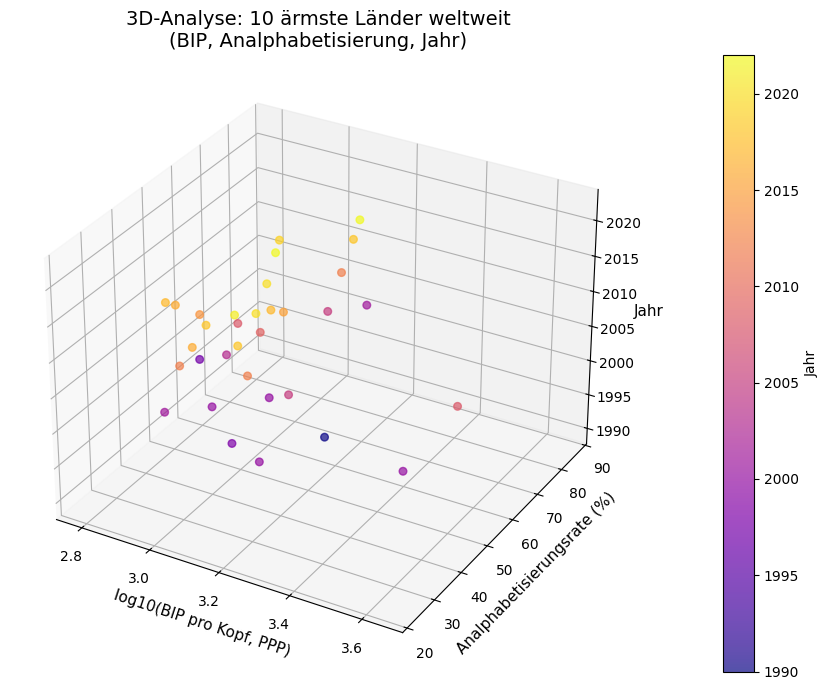

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Für 3D-Plot


FILE = "literacy-rate-vs-gdp-per-capita.csv"
GDP_COL_RAW = 'GDP per capita, PPP (constant 2021 international $)'
LITERACY_COL_RAW = 'Literacy rate among adults'
START_YEAR = 1985
END_YEAR = 2023
GDP_COL_ALIAS = 'BIP pro Kopf'

# Daten laden
try:
    df_rohdaten = pd.read_csv(FILE)
except FileNotFoundError:
    # Dieser Fehler tritt auf, wenn die Datei fehlt.
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# Spalten umbenennen und Analphabetisierungsrate berechnen
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    LITERACY_COL_RAW: 'Alphabetisierungsrate',
    GDP_COL_RAW: GDP_COL_ALIAS # Wichtig: BIP pro Kopf als Alias setzen
}, inplace=True)

df_rohdaten['Analphabetisierungsrate (%)'] = 100 - df_rohdaten['Alphabetisierungsrate']


# Ärmste 10 Länder finden
gdp_latest = (
    df_rohdaten
    .dropna(subset=[GDP_COL_ALIAS])
    .sort_values("Jahr")
    .groupby("Land", as_index=False)
    .tail(1)
)
poorest_10 = gdp_latest.nsmallest(10, GDP_COL_ALIAS)["Land"].tolist()


# Daten für den 3D-Plot vorbereiten (Single Block)
df_3d = (
    df_rohdaten
    .query("Land in @poorest_10")
    .dropna(subset=['Analphabetisierungsrate (%)', GDP_COL_ALIAS])
)
df_3d = df_3d[(df_3d["Jahr"] >= START_YEAR) & (df_3d["Jahr"] <= END_YEAR)]


# Erstellung 3D Plot

x = np.log10(df_3d[GDP_COL_ALIAS]) 
y = df_3d["Analphabetisierungsrate (%)"]
z = df_3d["Jahr"]

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

sc = ax.scatter(
    x, y, z,
    c=z,
    cmap="plasma",
    s=30,
    alpha=0.7
)

ax.set_title("3D-Analyse: 10 ärmste Länder weltweit\n(BIP, Analphabetisierung, Jahr)", fontsize=14)
ax.set_xlabel("log10(BIP pro Kopf, PPP)", fontsize=11)
ax.set_ylabel("Analphabetisierungsrate (%)", fontsize=11)
ax.set_zlabel("Jahr", fontsize=11)

cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Jahr", fontsize=10)

plt.tight_layout()
plt.show()

Die 3D-Grafik zeigt die Entwicklung von Analphabetisierung und wirtschaftlichem Wohlstand der zehn ärmsten Länder über die Zeit.
Auf der X-Achse ist das logarithmierte BIP pro Kopf dargestellt, auf der Y-Achse die Analphabetisierungsrate und auf der Z-Achse das Jahr.
Die Darstellung verdeutlicht, dass Länder mit sehr niedrigem Einkommen über viele Jahre hinweg hohe Analphabetisierungsraten aufweisen. Der Sudan gehört zu einem der Top 10.


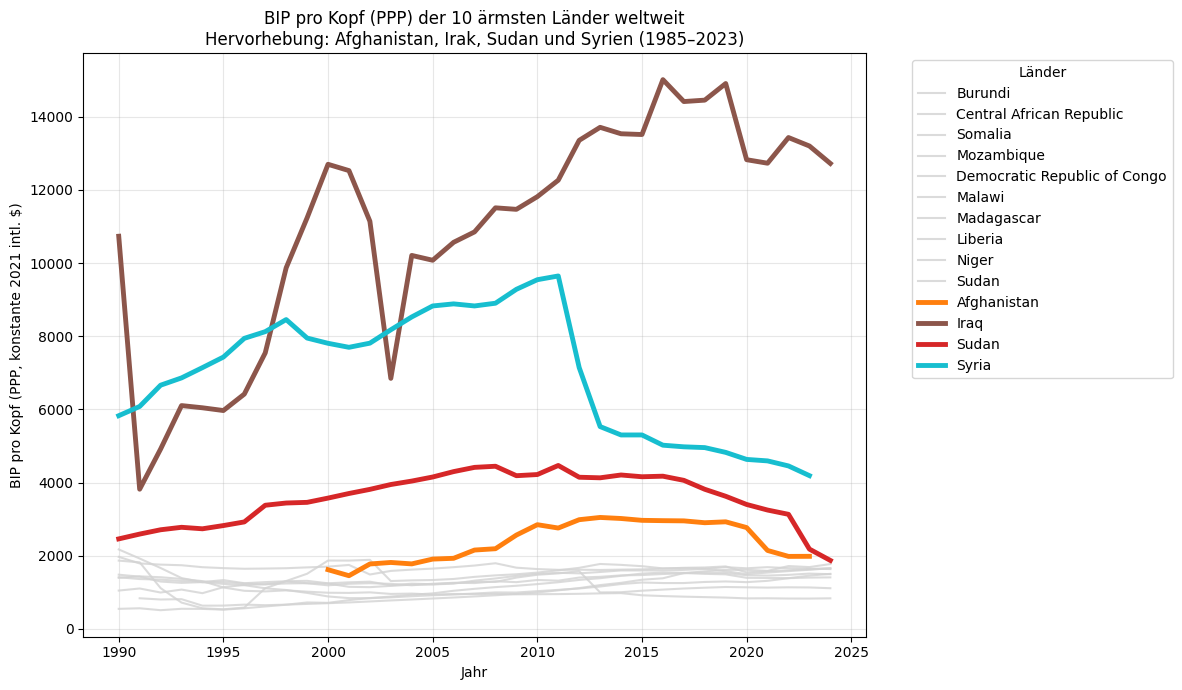

In [33]:
import matplotlib.pyplot as plt


meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"]

# Spaltenname
gdp_col = "BIP pro Kopf"

plt.figure(figsize=(12,7))

# Hintergrund: 10 ärmste Länder
for land in poorest_10:
    land_df = (
        df[(df["Land"] == land) & (df["Jahr"] >= 1985)]
        .sort_values("Jahr")
    )
    plt.plot(
        land_df["Jahr"],
        land_df[gdp_col],
        color="lightgray",
        linewidth=1.5,
        alpha=0.8,
        label=land
    )

# Hervorhebung: meine Länder 
farben = {
    "Afghanistan": "tab:orange",
    "Iraq": "tab:brown",
    "Sudan": "tab:red",
    "Syria": "tab:cyan"
}

for land in meine_laender:
    land_df = (
        df[(df["Land"] == land) & (df["Jahr"] >= 1985)]
        .sort_values("Jahr")
    )
    if not land_df.empty:
        plt.plot(
            land_df["Jahr"],
            land_df[gdp_col],
            linewidth=3.5,          # zum dicker machen
            color=farben[land],
            label=land
        )

# Titel & Achsen
plt.title(
    "BIP pro Kopf (PPP) der 10 ärmsten Länder weltweit\n"
    "Hervorhebung: Afghanistan, Irak, Sudan und Syrien (1985–2023)"
)
plt.xlabel("Jahr")
plt.ylabel("BIP pro Kopf (PPP, konstante 2021 intl. $)")
plt.grid(alpha=0.3)

# Legende
plt.legend(
    title="Länder",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


Obwohl alle dargestellten Länder zu den wirtschaftlich ärmsten zählen, zeigen sich deutliche Unterschiede im BIP pro Kopf. Alle 4 Länder, ausser dem Sudan gehören nicht zu den Top 10 ärmsten Ländern, zeigen aber grosse Schwankungen in ihrem BIP. Dies zeigt, dass in diesen Ländern trotzdem eine Instabilität darliegt.

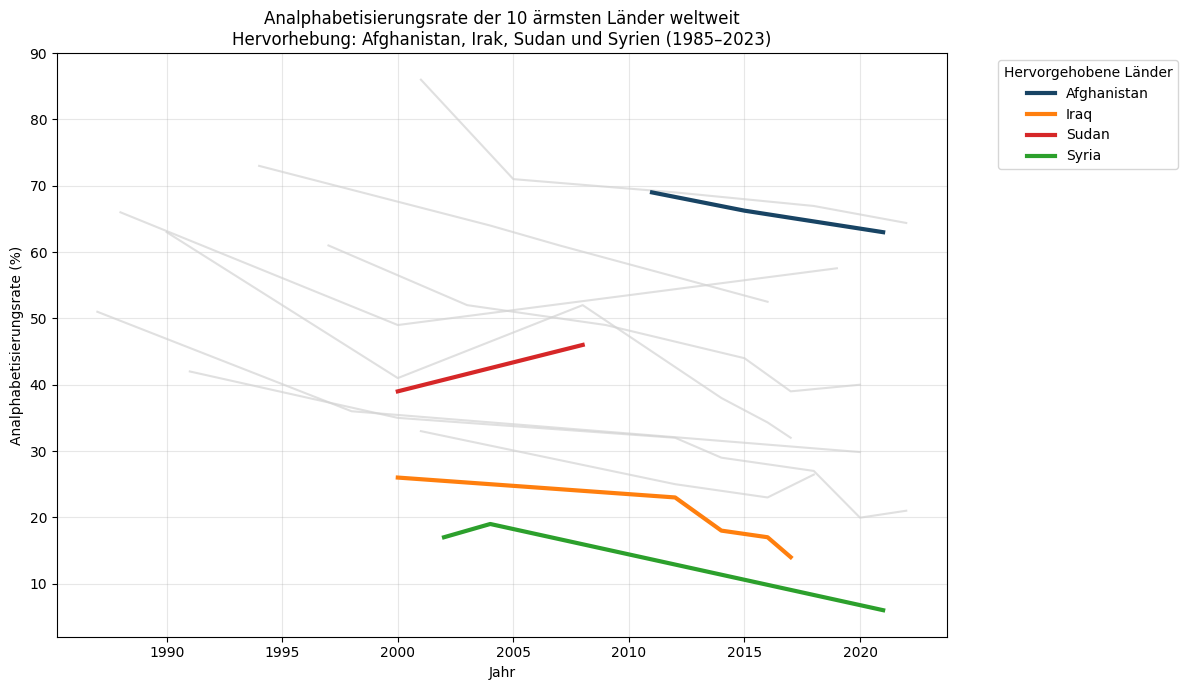

In [34]:
import matplotlib.pyplot as plt

meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"]

farben = {
    "Afghanistan":"#184464",  # blau
    "Iraq": "#ff7f0e",         # orange
    "Sudan": "#d62728",        # rot
    "Syria": "#2ca02c"         # grün
}

start_jahr = 1985
end_jahr = 2023

df_plot = df[df["Jahr"].between(start_jahr, end_jahr)].copy()

# 10 ärmste Länder nach BIP
aermste_10 = (
    df_plot
    .groupby("Land")["BIP pro Kopf"]
    .mean()
    .sort_values()
    .head(10)
    .index
    .tolist()
)

plt.figure(figsize=(12, 7))

#  Hintergrund: 10 ärmste Länder (grau)
for land in aermste_10:
    land_df = df_plot[
        (df_plot["Land"] == land) &
        (df_plot["Analphabetisierungsrate (%)"].notna())
    ].sort_values("Jahr")

    if not land_df.empty:
        plt.plot(
            land_df["Jahr"],
            land_df["Analphabetisierungsrate (%)"],
            color="lightgrey",
            linewidth=1.5,
            alpha=0.7
        )

#  Hervorhebung: deine Länder (IMMER zeichnen, wenn Daten existieren)
for land in meine_laender:
    land_df = df_plot[
        (df_plot["Land"] == land) &
        (df_plot["Analphabetisierungsrate (%)"].notna())
    ].sort_values("Jahr")

    if not land_df.empty:
        plt.plot(
            land_df["Jahr"],
            land_df["Analphabetisierungsrate (%)"],
            linewidth=3,
            color=farben[land],
            label=land
        )

plt.title(
    "Analphabetisierungsrate der 10 ärmsten Länder weltweit\n"
    "Hervorhebung: Afghanistan, Irak, Sudan und Syrien (1985–2023)"
)
plt.xlabel("Jahr")
plt.ylabel("Analphabetisierungsrate (%)")
plt.grid(alpha=0.3)

plt.legend(
    title="Hervorgehobene Länder",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


Die Analphabetisierungsrate wird für dieselben Länder und denselben Zeitraum dargestellt wie das BIP pro Kopf. Dadurch lassen sich wirtschaftliche und bildungsbezogene Entwicklungen visuell vergleichen, ohne Daten künstlich zu verknüpfen.

## 3.4 Unsere 4 Länder im Vergleich mit den 10 reichsten Ländern weltweit

In [35]:
import pandas as pd


FILE = "literacy-rate-vs-gdp-per-capita.csv"
GDP_COL_RAW = 'GDP per capita, PPP (constant 2021 international $)'

try:
    
    df_rohdaten = pd.read_csv(FILE)
except FileNotFoundError:
    print(f"FEHLER: Datei '{FILE}' nicht gefunden. Bitte Pfad prüfen.")
    exit()

# Spalten umbenennen (definiert den Spaltennamen)
df_rohdaten.rename(columns={
    'Entity': 'Land',
    'Year': 'Jahr',
    GDP_COL_RAW: 'BIP pro Kopf' 
}, inplace=True)

# Spaltennamen-Alias setzen
gdp_col_alias = 'BIP pro Kopf'



# Neuester BIP-Wert pro Land (definiert 'latest_rich')
latest_rich = (
    df_rohdaten
    # dropna(subset=[gdp_col]) -> mit Alias
    .dropna(subset=[gdp_col_alias])
    # sort_values("Year") -> mit Alias
    .sort_values("Jahr") 
    # groupby("Entity") -> mit Alias
    .groupby("Land", as_index=False) 
    .tail(1)
)
 
# 10 reichste Länder
# nlargest(10, gdp_col)["Entity"] -> mit Aliasen
richest_10 = latest_rich.nlargest(10, gdp_col_alias)["Land"].tolist()

print("10 Länder mit dem höchsten BIP pro Kopf (Neuester verfügbarer Wert)")
print(richest_10)

10 Länder mit dem höchsten BIP pro Kopf (Neuester verfügbarer Wert)
['Singapore', 'Luxembourg', 'Ireland', 'Macao', 'Qatar', 'Bermuda', 'Norway', 'Switzerland', 'Brunei', 'Cayman Islands']


Die Liste zeigt nun die 10 Länder mit dem höchsten BIP auf, darunter gehört auch die Schweiz.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt


df_raw = pd.read_csv("literacy-rate-vs-gdp-per-capita.csv")

def pick_col(cols, candidates):
    """Gibt die erste passende Spalte aus candidates zurück, sonst None."""
    for c in candidates:
        if c in cols:
            return c
    return None

cols = df_raw.columns.tolist()

country_col = pick_col(cols, ["Land", "Entity"])
year_col    = pick_col(cols, ["Jahr", "Year"])


lit_col = pick_col(cols, [
    "Alphabetisierungsrate",
    "Literacy rate among adults",
    "Literacy rate, adult total (% of people ages 15 and above)",
    "Literacy rate, adult total"
])

# GDP pro Kopf
gdp_col = pick_col(cols, [
    "BIP pro Kopf",
    "GDP per capita, PPP (constant 2021 international $)",
    "GDP per capita, PPP",
    "gdp_per_capita"
])

if country_col is None or year_col is None:
    raise KeyError(f"Land/Entity oder Jahr/Year nicht gefunden. Spalten: {cols}")

if lit_col is None:
    raise KeyError(f"Keine Literacy/Alphabetisierungs-Spalte gefunden. Spalten: {cols}")

if gdp_col is None:
    raise KeyError(f"Keine BIP-pro-Kopf-Spalte gefunden. Spalten: {cols}")

# Einheitliches df bauen
df = df_raw.rename(columns={
    country_col: "Land",
    year_col: "Jahr",
    lit_col: "Alphabetisierungsrate",
    gdp_col: "BIP pro Kopf"
}).copy()

# numerisch machen 
df["Jahr"] = pd.to_numeric(df["Jahr"], errors="coerce")
df["Alphabetisierungsrate"] = pd.to_numeric(df["Alphabetisierungsrate"], errors="coerce")
df["BIP pro Kopf"] = pd.to_numeric(df["BIP pro Kopf"], errors="coerce")

# Analphabetisierung berechnen
df["Analphabetisierungsrate (%)"] = 100 - df["Alphabetisierungsrate"]

# Extremwerte wie -10000 rausfiltern 
df = df[df["Jahr"].between(0, 3000)].copy()



meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"]
start_jahr, end_jahr = 1985, 2023

df_plot = df[df["Jahr"].between(start_jahr, end_jahr)].copy()



# 10 reichste / 10 ärmste Länder bestimmen (nach aktuellstem verfügbaren BIP)
def get_latest_gdp_per_country(df_in):
    tmp = df_in.dropna(subset=["BIP pro Kopf"]).sort_values("Jahr")
    latest = tmp.groupby("Land", as_index=False).tail(1)  # letzte Zeile je Land
    return latest

gdp_latest = get_latest_gdp_per_country(df_plot)

poorest_10 = gdp_latest.nsmallest(10, "BIP pro Kopf")["Land"].tolist()
richest_10 = gdp_latest.nlargest(10, "BIP pro Kopf")["Land"].tolist()



# Plot-Funktion (Hintergrund + Hervorhebung)

def plot_lines_background_plus_highlight(df_in, countries_bg, countries_hi, y_col, title, y_label):
    plt.figure(figsize=(12, 7))

    # Hintergrundländer (verblassen)
    for land in countries_bg:
        land_df = df_in[df_in["Land"] == land].sort_values("Jahr")
        land_df = land_df.dropna(subset=[y_col])
        if land_df.empty:
            continue
        plt.plot(
            land_df["Jahr"], land_df[y_col],
            alpha=0.25, linewidth=1.5,
            label=land
        )

    # Hervorgehobene Länder (dicker)
    for land in countries_hi:
        land_df = df_in[df_in["Land"] == land].sort_values("Jahr")
        land_df = land_df.dropna(subset=[y_col])
        if land_df.empty:
            continue
        plt.plot(
            land_df["Jahr"], land_df[y_col],
            linewidth=3.5,
            linestyle="-",
            label=f"{land} (Highlight)"
        )

    plt.title(title)
    plt.xlabel("Jahr")
    plt.ylabel(y_label)
    plt.grid(alpha=0.3)

    # Legende: 
    plt.legend(title="Länder", bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()



# 6) Extra: "Aktuellstes Jahr, wo BIP UND Analphabetisierung vorhanden ist" pro Land
print("\n--- Aktuellstes Jahr mit BOTH (BIP & Analphabetisierung) pro ausgewähltem Land ---")
both = df_plot.dropna(subset=["BIP pro Kopf", "Analphabetisierungsrate (%)"]).sort_values("Jahr")
latest_both = (both[both["Land"].isin(meine_laender)]
               .groupby("Land", as_index=False)
               .tail(1)[["Land", "Jahr", "BIP pro Kopf", "Analphabetisierungsrate (%)"]])

print(latest_both.to_markdown(index=False))



--- Aktuellstes Jahr mit BOTH (BIP & Analphabetisierung) pro ausgewähltem Land ---
| Land        |   Jahr |   BIP pro Kopf |   Analphabetisierungsrate (%) |
|:------------|-------:|---------------:|------------------------------:|
| Sudan       |   2008 |        4446.41 |                            46 |
| Iraq        |   2017 |       14417.6  |                            14 |
| Afghanistan |   2021 |        2144.17 |                            63 |
| Syria       |   2021 |        4592.84 |                             6 |


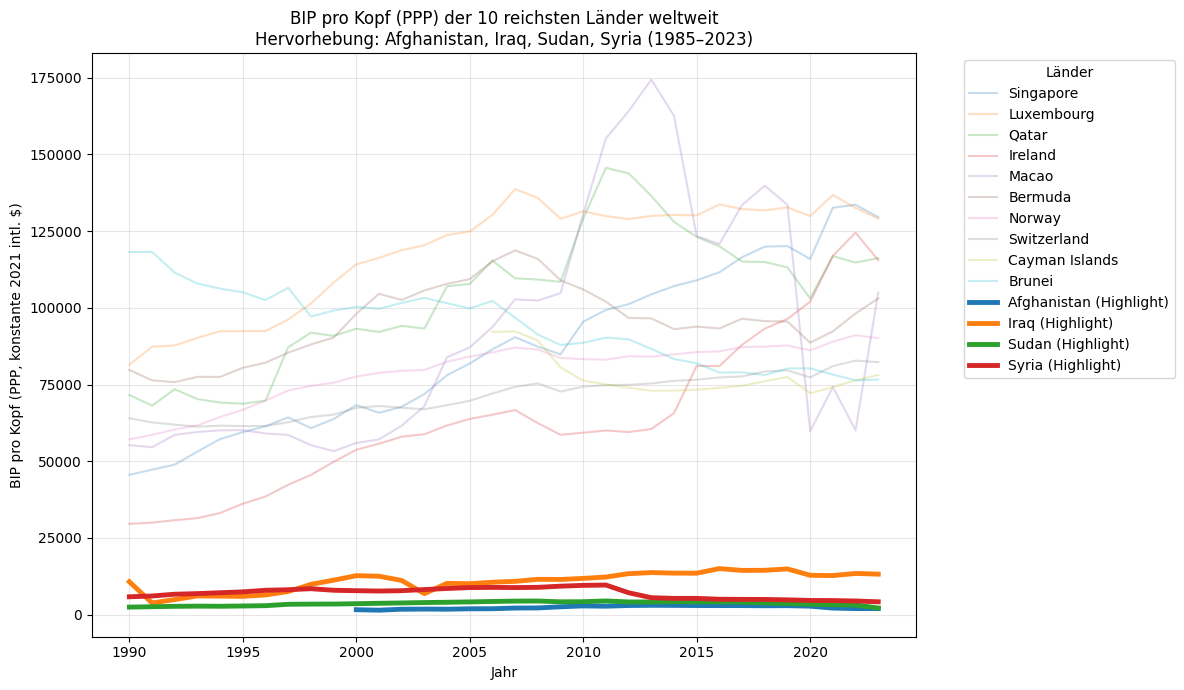

In [37]:
# Reichste 10 + meine Länder — BIP
plot_lines_background_plus_highlight(
    df_plot,
    countries_bg=richest_10,
    countries_hi=meine_laender,
    y_col="BIP pro Kopf",
    title=f"BIP pro Kopf (PPP) der 10 reichsten Länder weltweit\nHervorhebung: {', '.join(meine_laender)} ({start_jahr}–{end_jahr})",
    y_label="BIP pro Kopf (PPP, konstante 2021 intl. $)"
)

Die Grafik verdeutlicht einen enormen Abstand zwischen den reichsten Ländern der Welt und den ausgewählten Vergleichsländern. Während die reichsten Länder über den gesamten Zeitraum ein hohes und relativ stabiles Einkommensniveau aufweisen, zeigen die Vergleichsländer eine deutlich volatilere Entwicklung. Die Vergleichsländer erscheinen in der Grafik nahezu am unteren Rand, was ihre wirtschaftliche Marginalisierung im globalen Kontext unterstreicht.

- Reichste Länder: 50.000–170.000 USD
- Vergleichsländer: unter 15.000 USD, meist deutlich darunter

-> Der Unterschied des BIP's zwischen den Top 10 reichsten Ländern und unseren Vergleichsländern beträgt teils das Zehn- bis Zwanzigfache

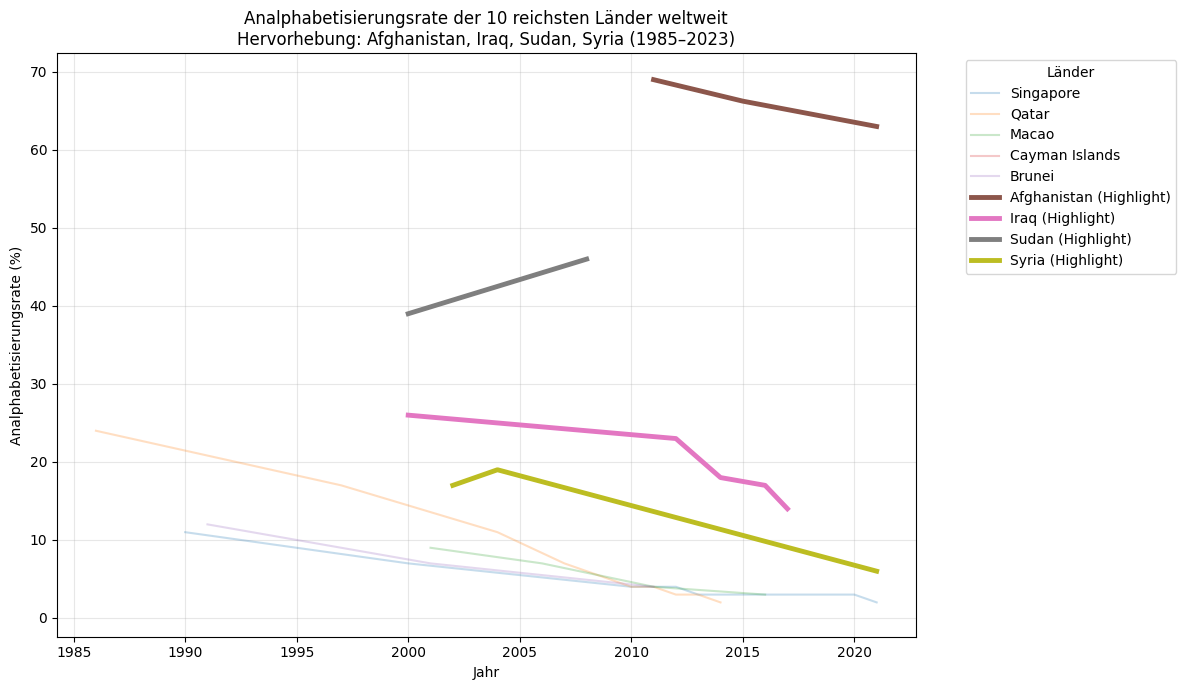

In [38]:

# Reichste 10 + meine Länder — Analphabetisierung
plot_lines_background_plus_highlight(
    df_plot,
    countries_bg=richest_10,
    countries_hi=meine_laender,
    y_col="Analphabetisierungsrate (%)",
    title=f"Analphabetisierungsrate der 10 reichsten Länder weltweit\nHervorhebung: {', '.join(meine_laender)} ({start_jahr}–{end_jahr})",
    y_label="Analphabetisierungsrate (%)"
)

Die Grafik zeigt die Analphabetisierungsrate in den zehn reichsten Ländern über den gesamten Zeitraum hinweg sehr niedrig bleibt. Dies unterstreicht den Zusammenhang mit dem wirtschaftlichen Wohlstand, stabilen Bildungssystem und hohen Alphabetisierung.

In [39]:
import pandas as pd

country_col = "Entity" if "Entity" in df.columns else "Land"
year_col    = "Year" if "Year" in df.columns else "Jahr"

lit_candidates = [
    "Literacy rate among adults",
    "Literacy rate, adult total (% of people ages 15 and above)",
    "Alphabetisierungsrate",
]
lit_col = next((c for c in lit_candidates if c in df.columns), None)

if lit_col is None:
    raise KeyError(f"Keine Literacy-Spalte gefunden. Verfügbar: {df.columns.tolist()}")

# Zeitraum filtern
df_plot = df[df[year_col].between(1985, 2023)].copy()

# Analphabetisierung berechnen
df_plot["Analphabetisierungsrate (%)"] = 100 - df_plot[lit_col]

# Kontrolle
df_plot[[country_col, year_col, lit_col, "Analphabetisierungsrate (%)"]].head()


,Land,Jahr,Alphabetisierungsrate,Analphabetisierungsrate (%)
1,Afghanistan,2011,31.00000,69.00000
2,Afghanistan,2015,33.75384,66.24616
3,Afghanistan,2021,37.00000,63.00000
4,Afghanistan,2000,NaN,NaN
5,Afghanistan,2001,NaN,NaN


In [40]:
df_plot = df_plot.rename(columns={"Entity": "Land"})
df_plot.columns


Index(['Land', 'Code', 'Jahr', 'Alphabetisierungsrate', 'BIP pro Kopf',
       'Population (historical)', 'World regions according to OWID',
       'Analphabetisierungsrate (%)'],
      dtype='object')

In [41]:
meine_laender = ["Afghanistan", "Iraq", "Sudan", "Syria"]

df_meine = df_plot[df_plot["Land"].isin(meine_laender)]


In [42]:
df_plot[["Land", "Jahr", "Analphabetisierungsrate (%)"]].head()


,Land,Jahr,Analphabetisierungsrate (%)
1,Afghanistan,2011,69.00000
2,Afghanistan,2015,66.24616
3,Afghanistan,2021,63.00000
4,Afghanistan,2000,NaN
5,Afghanistan,2001,NaN


Mit dieser Liste kann man den Zeitraum und Veränderung der Analphabetisierung beobachten. Bsp. Afghanistan ist die Analphabetisierungsrate innerhalb von zwanzig Jahren (2011 - 2021) nur um 6% gesunken. Diese Liste zeigt alle Zeiträume an, also ohne Begrenzung.

In [43]:
durchschnitt_ana = (
    df_meine
    .groupby("Land")["Analphabetisierungsrate (%)"]
    .mean()
    .round(2)
)

durchschnitt_ana_df = durchschnitt_ana.reset_index()

durchschnitt_ana_df.index += 1
durchschnitt_ana_df.index.name = "Nr."

print(durchschnitt_ana_df)


            Land  Analphabetisierungsrate (%)
Nr.                                          
1    Afghanistan                        66.08
2           Iraq                        19.60
3          Sudan                        42.50
4          Syria                        14.00


Diese Liste zeigt die durschnitliche Analphabetisierungsrate, über alle Datenpunkte an. Die durchschnittliche Analphabetisierungsrate ist in Afghanistan und Sudan besonders hoch, während Irak und Syrien trotz höherem BIP niedrigere, jedoch weiterhin erhöhte Werte aufweisen. Dies deutet darauf hin, dass wirtschaftliche Leistungsfähigkeit allein Bildungsdefizite nicht vollständig erklärt



## 4. Diskussion und Fazit
Die Analyse zeigt einen deutlichen Zusammenhang zwischen dem wirtschaftlichen Entwicklungsstand eines Landes und seiner Analphabetisierungsrate. Länder mit hohem BIP pro Kopf weisen durchgehend sehr niedrige Analphabetisierungsraten auf, während wirtschaftlich schwache Länder häufig mit hohen Bildungsdefiziten konfrontiert sind.
(Siehe Grafen BIP & Analphabetisierung der 10 ärmsten und reichsten Ländern)

Die Analyse unterliegt mehreren Einschränkungen. Erstens sind nicht für alle Länder und Jahre vollständige Datensätze verfügbar, wodurch Vergleiche teilweise auf unterschiedliche Zeiträume beschränkt sind. Zweitens beschreibt der beobachtete Zusammenhang zwischen BIP pro Kopf und Analphabetisierungsrate eine Korrelation, jedoch keine Kausalität. Weitere Faktoren wie politische Stabilität, Bildungspolitik und soziale Ungleichheit spielen eine wesentliche Rolle.

Für diese Interpretation wurden insgesamt vier Länder rausgesucht: 
Afghanistan, Iran, Sudan und Syrien.

Ursachenanalyse:

Afghanistan
-	Jahrzehntelanger Krieg
-	Eingeschränkter Zugang zu Bildung, insbesondere für Frauen und Mäschen
-	Extreme Armut 
-	Schwache staatliche Strukturen

Trotz wirtschaftlichen Verbesserungen kann die Bildung nicht greifen, da grundsätzliche gesellschaftliche Vorraussetzungen fehlen.

Sudan
-	Politische Instabilität
-	Bürgerkirege und ethnische Knoflikte
-	Geringe Investitionen in Bildung
-	Hohe Landesbevölkerung mit schlechter Bildungsversorgung

Hier leidet die Bildung unter langfristiger Vernachlässigung und fehlender staatlicher Stabilität

Syrien
-	Seit 2011 anhaltender Bürgerkrieg
-	Zerstörung von Bildungsstätten
-	Wirtschaftlicher Einbruch trotz früherer guter Bildungsstruktur
-	Flüchtlingsbewegungne, Generationsverlust

Irak
-	Politische Insatbilität nach 2003
-	Regionale Ungleichheiten
-	Dennoch hohe Staatseinnahmen durch Öl

Um Verzerrungen zu vermeiden, wurden BIP und Analphabetisierungsrate in vielen Grafiken getrennt dargestellt. Eine direkte Zusammenführung beider Variablen erfolgte nur dort, wo dies methodisch sinnvoll war. Dadurch bleibt die Analyse transparent und nachvollziehbar.

Der Vergleich zeigt, dass niedrige Bildungsniveaus nicht ausschließlich durch wirtschaftliche Armut erklärt werden können. Während Afghanistan und Sudan sowohl wirtschaftlich als auch bildungsbezogen stark benachteiligt sind, verdeutlicht der Irak, dass natürliche Ressourcen und staatliche Einnahmen Bildungsdefizite teilweise abfedern können. Syrien hingegen zeigt, wie stark Konflikte auch vormals funktionierende Bildungssysteme zerstören können.

Die Analyse der vier Länder macht deutlich, dass Analphabetisierung ein vielschichtiges Problem ist, das neben wirtschaftlichen Faktoren maßgeblich durch politische Stabilität, gesellschaftliche Strukturen und langfristige Bildungspolitik beeinflusst wird.
